# 01 — Análise Exploratória de Dados

**Dimensão 3 da rúbrica — 20 pontos.**

Toda visualização precisa de um parágrafo de interpretação logo abaixo.
Gráfico sem leitura perde metade dos pontos do critério.

In [ ]:
#Libs - Bibliotecas importantes

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np


# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

RAW_1 = Path("/content") / "data" / "raw" / "application_record.csv"
RAW_2 = Path("/content") / "data" / "raw" / "credit_record.csv"


PROCESSED = Path("..") / "data" / "processed"
TARGET = "STATUS"

pd.set_option("display.max_columns", None)

In [ ]:
#Leitura do dataframe e visualização das cinco primeiras linhas.

df_application = pd.read_csv(RAW_1)
df_application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


Leitura do dataframe e visualização das cinco primeiras linhas.

## 1. Visão geral

_Dimensões, tipos e primeira impressão do dataset._

In [ ]:
print(f"Tamanho do df_application: {df_application.shape}")

Tamanho do df_application: (438557, 18)


In [ ]:
#Visualizar os tipos das variáveis.

df_application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

O df_application possui 438557 registros e 18 colunas. Ao analisar os tipos de dados com o comando .info(), observamos que há 02 variáveis tipo float, 8 tipo int e 08 como texto (tipo object).

In [ ]:
#Verificando a existência de dados nulos.

df_application.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


Verificando a existência de dados nulos e como resultado trouxe que a coluna OCCUPATION_TYPE possui 134203 linhas em branco.

In [ ]:
#Substituir os dados em branco da variável OCCUPATION_TYPE por "Unknown".

df_application["OCCUPATION_TYPE"] = df_application["OCCUPATION_TYPE"].fillna("Unknown")

In [ ]:
#Verificando a existência de dados duplicados.

df_application.duplicated().sum()

np.int64(0)

Verificando a existência de dados duplicados e como resultado trouxe que a quantidade de dados duplicados é 0.

In [ ]:
#Verificando a existência de IDs duplicados.

df_application["ID"].duplicated().sum()

np.int64(47)

Verificando a existência de IDs duplicados e como resultado trouxe a quantidade 47.

In [ ]:
#Para os IDs duplicados, verificar se os dados das outras variáveis estão duplicados também.

duplicados = df_application[df_application["ID"].duplicated(keep=False)]
duplicados.sort_values(by="ID")


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
425023,7022197,F,N,Y,0,450000.0,Commercial associate,Higher education,Separated,House / apartment,-19813,-1799,1,0,0,1,Unknown,1.0
426818,7022197,M,Y,Y,3,135000.0,Working,Secondary / secondary special,Married,House / apartment,-11945,-735,1,0,0,1,Laborers,5.0
431911,7022327,M,Y,Y,0,256500.0,Commercial associate,Higher education,Married,House / apartment,-21503,-1674,1,0,0,1,Core staff,2.0
431545,7022327,F,N,Y,0,135000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-14771,-5298,1,0,0,0,High skill tech staff,1.0
425486,7023108,M,Y,Y,1,67500.0,Working,Secondary / secondary special,Married,House / apartment,-15156,-1696,1,1,0,0,Core staff,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426563,7836711,F,N,Y,2,292500.0,Working,Higher education,Married,House / apartment,-13747,-4386,1,0,1,0,Accountants,4.0
428620,7836971,F,N,Y,0,103500.0,Working,Secondary / secondary special,Civil marriage,House / apartment,-13383,-2798,1,0,1,0,Sales staff,2.0
421464,7836971,M,Y,N,1,157500.0,Working,Secondary / secondary special,Married,House / apartment,-13771,-5520,1,0,0,0,Unknown,3.0
422068,7838075,M,N,Y,0,337500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-18198,-1275,1,0,0,1,Drivers,2.0


Verificando as linhas com os IDs duplicados, ordenando o resultado pelo campo ID. IDs repetidos, porém, pela visualização dos dados acima, as outras colunas são diferentes.

In [ ]:
# Lista de colunas sem a coluna ID

cols_sem_id = df_application.columns.drop('ID')

# Linhas consideradas duplicadas ignorando o ID

duplicadas = df_application[df_application.duplicated(subset=cols_sem_id, keep=False)]

print(f"Quantidade de linhas duplicadas (ignorando ID): {len(duplicadas)}")

duplicadas.sort_values(by=list(cols_sem_id))

Quantidade de linhas duplicadas (ignorando ID): 423253


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
273113,6093713,F,N,N,0,26100.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21003,365243,1,0,0,0,Unknown,2.0
436891,6093712,F,N,N,0,26100.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21003,365243,1,0,0,0,Unknown,2.0
92482,5369432,F,N,N,0,27000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-20794,365243,1,0,0,0,Unknown,2.0
92483,5369433,F,N,N,0,27000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-20794,365243,1,0,0,0,Unknown,2.0
92484,5369434,F,N,N,0,27000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-20794,365243,1,0,0,0,Unknown,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84129,5342638,M,Y,Y,5,810000.0,Working,Secondary / secondary special,Married,House / apartment,-14914,-2593,1,0,0,0,Laborers,7.0
84130,5342639,M,Y,Y,5,810000.0,Working,Secondary / secondary special,Married,House / apartment,-14914,-2593,1,0,0,0,Laborers,7.0
20441,5061207,M,Y,Y,14,225000.0,Working,Secondary / secondary special,Separated,House / apartment,-17754,-1689,1,0,0,0,Drivers,15.0
20442,5061210,M,Y,Y,14,225000.0,Working,Secondary / secondary special,Separated,House / apartment,-17754,-1689,1,0,0,0,Drivers,15.0


In [ ]:
#Quantas linhas são repetidas, ignorando a variável 'ID'.

df_application.duplicated(subset=df_application.columns.drop('ID')).sum()

np.int64(348472)

O resultado indica que existem 348.472 linhas com valores exatamente iguais nas demais colunas, mesmo que possuam IDs diferentes

Concluímos que há 348472 registros duplicados (sem a coluna do ID). Então seriam 90085 registros não duplicados, desconsiderando a coluna ID. Tratar apenas os 90085 registros.

In [ ]:
#Criar um dataframe com 90085 registros não duplicados.

df_application_cleaned = df_application.drop_duplicates(subset=df_application.columns.drop('ID')).copy()

In [ ]:
#Tamanho do nvo dataframe
df_application_cleaned.shape

(90085, 18)

In [ ]:
df_application_cleaned.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
7,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,Unknown,1.0
10,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,-16872,-769,1,1,1,1,Accountants,2.0


In [ ]:
df_application_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90085 entries, 0 to 438553
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   90085 non-null  int64  
 1   CODE_GENDER          90085 non-null  object 
 2   FLAG_OWN_CAR         90085 non-null  object 
 3   FLAG_OWN_REALTY      90085 non-null  object 
 4   CNT_CHILDREN         90085 non-null  int64  
 5   AMT_INCOME_TOTAL     90085 non-null  float64
 6   NAME_INCOME_TYPE     90085 non-null  object 
 7   NAME_EDUCATION_TYPE  90085 non-null  object 
 8   NAME_FAMILY_STATUS   90085 non-null  object 
 9   NAME_HOUSING_TYPE    90085 non-null  object 
 10  DAYS_BIRTH           90085 non-null  int64  
 11  DAYS_EMPLOYED        90085 non-null  int64  
 12  FLAG_MOBIL           90085 non-null  int64  
 13  FLAG_WORK_PHONE      90085 non-null  int64  
 14  FLAG_PHONE           90085 non-null  int64  
 15  FLAG_EMAIL           90085 non-null  int

In [ ]:
#Analisar a variável DAYS_EMPLOYED com o valor 365243.

(df_application_cleaned["DAYS_EMPLOYED"] ==365243).sum()

np.int64(15687)

São 15687 linhas que aparecem o valor 365243. Conforme dicionário de dados disponibilizado significa pessoas desempregadas.

In [ ]:
#Identificar padrão.

df_application_cleaned.loc[df_application_cleaned["DAYS_EMPLOYED"] == 365243, ["DAYS_EMPLOYED", "OCCUPATION_TYPE"]]

,DAYS_EMPLOYED,OCCUPATION_TYPE
7,365243,Unknown
76,365243,Unknown
160,365243,Unknown
216,365243,Unknown
239,365243,Unknown
...,...,...
438449,365243,Unknown
438499,365243,Unknown
438525,365243,Unknown
438545,365243,Unknown


Os espaços em branco na variável OCCUPATION_TYPE foram substituídos por "Unknown". Código gerado para analisar a proporção entre essas duas variáveis com os valores 365243 e Unknown.

In [ ]:
#Substituir a informação para desempregado em OCCUPATION_TYPE onde houver a informação 365243 em DAYS_EMPLOYED.

df_application_cleaned["OCCUPATION_TYPE"] = np.where(df_application_cleaned["DAYS_EMPLOYED"] == 365243, "Unemployed", df_application_cleaned["OCCUPATION_TYPE"])

In [ ]:
df_application_cleaned.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,YEARS_BIRTH,IS_UNEMPLOYED,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,58,0,3
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8
7,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,Unemployed,1.0,61,1,-1000
10,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,-16872,-769,1,1,1,1,Accountants,2.0,46,0,2


In [ ]:
#Converter dias de nascimento para idade em anos e para inteiro.
df_application_cleaned["YEARS_BIRTH"] = (df_application_cleaned["DAYS_BIRTH"] / -365).astype(int)

#Criar a coluna IS_UNEMPLOYED (1 para desempregado, 0 para empregado).
df_application_cleaned["IS_UNEMPLOYED"] = (df_application_cleaned["DAYS_EMPLOYED"] == 365243).astype(int)

#Converter dias de emprego para anos.
df_application_cleaned["YEARS_EMPLOYED"] = (df_application_cleaned["DAYS_EMPLOYED"] / -365 ).astype(int)

In [ ]:
df_application_cleaned.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,YEARS_BIRTH,IS_UNEMPLOYED,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,58,0,3
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8
7,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,Unemployed,1.0,61,1,-1000
10,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,-16872,-769,1,1,1,1,Accountants,2.0,46,0,2


In [ ]:
#Substituir -1000 em YEARS_UNEMPLOYED para 0 (desempregados).
df_application_cleaned["YEARS_EMPLOYED"] = df_application_cleaned["YEARS_EMPLOYED"].replace(-1000, 0)

#Excluir as variáveis DAYS_BIRTH e DAYS_EMPLOYED.
df_application_cleaned = df_application_cleaned.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED'])

In [ ]:
df_application_cleaned.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,YEARS_BIRTH,IS_UNEMPLOYED,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,1,0,0,Unknown,2.0,32,0,12
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Security staff,2.0,58,0,3
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1,0,1,1,Sales staff,1.0,52,0,8
7,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,1,0,0,0,Unemployed,1.0,61,1,0
10,5008815,M,Y,Y,0,270000.0,Working,Higher education,Married,House / apartment,1,1,1,1,Accountants,2.0,46,0,2


In [ ]:
df_application_cleaned.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,90085.0,5.907760e+06,517295.769223,5008804.0,5465838.0,5952121.0,6289034.0,7995770.0
CNT_CHILDREN,90085.0,4.238108e-01,0.726697,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,90085.0,1.787001e+05,102462.973043,26100.0,112500.0,157500.0,225000.0,6750000.0
FLAG_MOBIL,90085.0,1.000000e+00,0.000000,1.0,1.0,1.0,1.0,1.0
FLAG_WORK_PHONE,90085.0,2.029528e-01,0.402200,0.0,0.0,0.0,0.0,1.0
FLAG_PHONE,90085.0,2.744963e-01,0.446263,0.0,0.0,0.0,1.0,1.0
FLAG_EMAIL,90085.0,1.002276e-01,0.300305,0.0,0.0,0.0,0.0,1.0
CNT_FAM_MEMBERS,90085.0,2.177288e+00,0.904672,1.0,2.0,2.0,3.0,20.0
YEARS_BIRTH,90085.0,4.306284e+01,11.660565,20.0,33.0,42.0,53.0,69.0
IS_UNEMPLOYED,90085.0,1.741355e-01,0.379228,0.0,0.0,0.0,0.0,1.0


In [ ]:
#Leitura do dataframe e visualização das cinco primeiras linhas.
df_credit = pd.read_csv(RAW_2)
df_credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [ ]:
print(f"Tamanho do df_credit: {df_credit.shape}")

Tamanho do df_credit: (1048575, 3)


In [ ]:
#Visualizar os tipos das variáveis.

df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


O df_credit possui 1048575 registros e 03 colunas. Ao analisar os tipos de dados com o comando .info(), observamos que há 02 variáveis tipo int e 01 como texto (tipo object).

In [ ]:
#Verificando a existência de dados nulos.

df_credit.isnull().sum()

,0
ID,0
MONTHS_BALANCE,0
STATUS,0


Como resultado trouxe que a quantidade de dados nulos é 0.

In [ ]:
#Verificando a existência de dados duplicados.

df_credit.duplicated().sum()

np.int64(0)

Como resultado trouxe que a quantidade de dados duplicados é 0.

In [ ]:
#Verificando a existência de IDs duplicados.

df_credit["ID"].duplicated().sum()

np.int64(1002590)

Como resultado trouxe a quantidade 1002590 cópias.

In [ ]:
duplicados = df_credit[df_credit["ID"].duplicated(keep=False)]
duplicados.sort_values(by="ID")

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
16,5001712,-12,0
...,...,...,...
1048560,5150487,-15,C
1048553,5150487,-8,C
1048554,5150487,-9,C
1048574,5150487,-29,C


1048176 representa o total de linhas que contem IDs que aparecem mais de uma vez, incluindo a primeira ocorrência de cada ID duplicado. Porém referem-se a meses diferentes.

In [ ]:
print(df_credit['ID'].nunique())
print(len(df_credit))

45985
1048575


45985 IDs únicos do total de 1048575 IDs.

In [ ]:
#Ocorrências na coluna STATUS.
df_credit["STATUS"].value_counts()

,count
STATUS,
C,442031
0,383120
X,209230
1,11090
5,1693
2,868
3,320
4,223


Conforme dicionário de dados disponibilizado: 0: 1-29 dias atrasados; 1: 30-59 dias atrasados; 2: 60-89 dias atrasados; 3: 90-119 dias atrasados; 4: 120-149 dias atrasados; 5: dívidas atrasadas ou incobráveis, perdas por mais de 150 dias; C: quitadas naquele mês; X: sem empréstimo no mês;


In [ ]:
#Ocorrências na coluna STATUS em percentual.
df_credit["STATUS"].value_counts(normalize=True) * 100

,proportion
STATUS,
C,42.155401
0,36.537205
X,19.953747
1,1.057626
5,0.161457
2,0.082779
3,0.030518
4,0.021267


## 2. Distribuição das variáveis

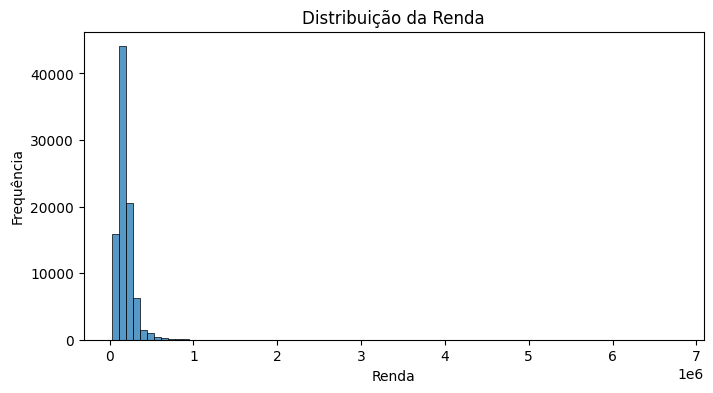

In [ ]:
#Histograma para AMT_INCOME_TOTAL.

plt.figure(figsize=(8,4))
sns.histplot(df_application_cleaned["AMT_INCOME_TOTAL"], bins=80)
plt.title("Distribuição da Renda")
plt.xlabel("Renda")
plt.ylabel("Frequência")
plt.show()

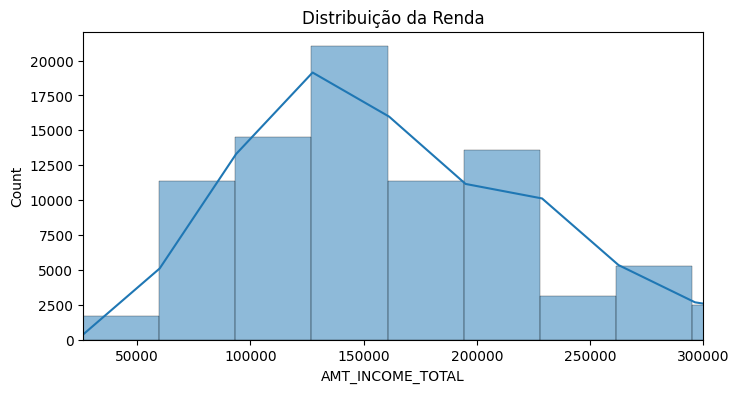

In [ ]:
#Histograma para AMT_INCOME_TOTAL.

plt.figure(figsize=(8,4))
sns.histplot(df_application_cleaned["AMT_INCOME_TOTAL"], kde=True, bins=200)
plt.title("Distribuição da Renda")
plt.xlim(26100, 300000)
plt.show()

**Interpretação:** O histograma da AMT_INCOME_TOTAL, com o eixo X limitado para melhor visualização, revela que a renda da maioria dos solicitantes está concentrada em faixas de valores mais baixos, com um pico claro entre 100.000 e 200.000. Há uma cauda longa à direita, indicando que poucos indivíduos possuem rendas significativamente mais altas, o que sugere uma distribuição assimétrica.

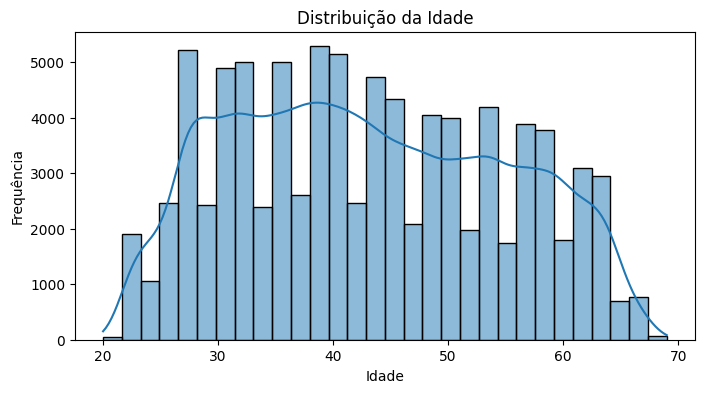

In [ ]:
#Histograma para YEARS_BIRTH.
plt.figure(figsize=(8,4))
sns.histplot(df_application_cleaned["YEARS_BIRTH"], kde=True, bins=30)
plt.title("Distribuição da Idade")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()

**Interpretação:** A distribuição da idade dos indivíduos, convertida para anos, mostra uma concentração maior de indivíduos nas faixas dos 30 e 40 anos. A distribuição é relativamente simétrica, com uma leve tendência para a esquerda.

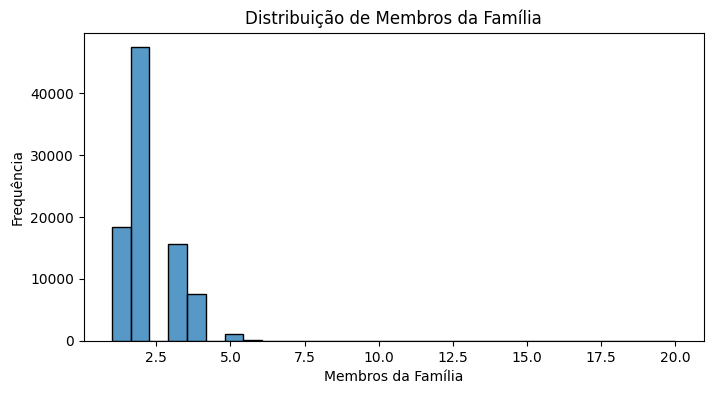

In [ ]:
#Histograma para CNT_FAM_MEMBERS.
plt.figure(figsize=(8,4))
sns.histplot(df_application_cleaned["CNT_FAM_MEMBERS"], bins =30)
plt.title("Distribuição de Membros da Família")
plt.xlabel("Membros da Família")
plt.ylabel("Frequência")
plt.show()

**Interpretação:** O histograma de CNT_FAM_MEMBERS mostra uma clara concentração de famílias com 2 membros (casais ou pais solteiros com um filho) e 1 membro (indivíduos solteiros). À medida que o número de membros da família aumenta, a frequência diminui drasticamente, indicando que famílias maiores são menos comuns na amostra.

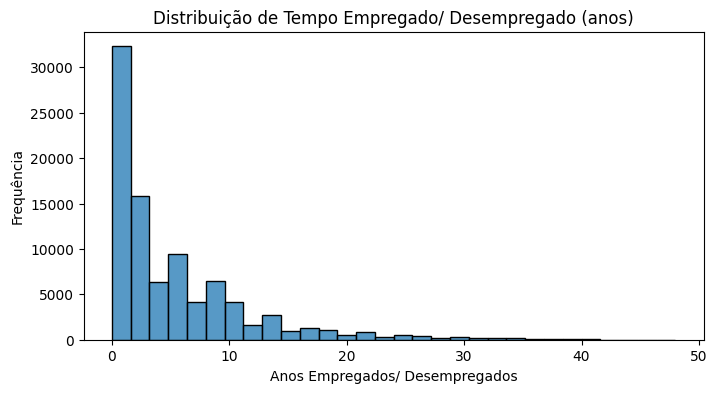

In [ ]:
#Histograma para YEARS_EMPLOYED.

plt.figure(figsize=(8,4))
sns.histplot(df_application_cleaned["YEARS_EMPLOYED"], bins=30)
plt.title("Distribuição de Tempo Empregado/ Desempregado (anos)")
plt.xlabel("Anos Empregados/ Desempregados")
plt.ylabel("Frequência")
plt.show()

**Interpretação:** O histograma da variável YEARS_EMPLOYED revela uma característica marcante: o pico mais alto está concentrado em zero anos de emprego, o que corresponde aos indivíduos classificados como 'Unemployed'. Após esse pico, a frequência diminui e o tempo em anos empregados  progressivamente aumenta, mostrando que há menos pessoas com muitos anos de emprego em comparação com as que têm menos anos.

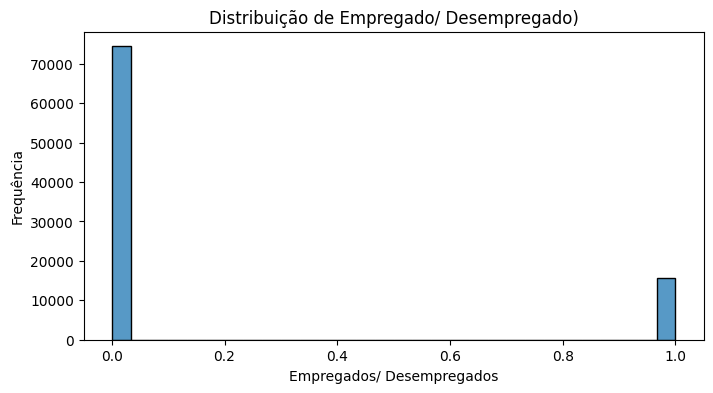

In [ ]:
#Histograma para IS-UNEMPLOYED.

plt.figure(figsize=(8,4))
sns.histplot(df_application_cleaned["IS_UNEMPLOYED"], bins=30)
plt.title("Distribuição de Empregado/ Desempregado)")
plt.xlabel("Empregados/ Desempregados")
plt.ylabel("Frequência")
plt.show()

A maioria dos indivíduos está empregada, em contrapartida os desempregados (365243) possui uma frequencia relevante perto de 20.000 registros. Por isso foi criada a variável IS-UNEMPLOYED para naõ misturar esses dois perfis na mesma escala numérica de tempo trabalhado.

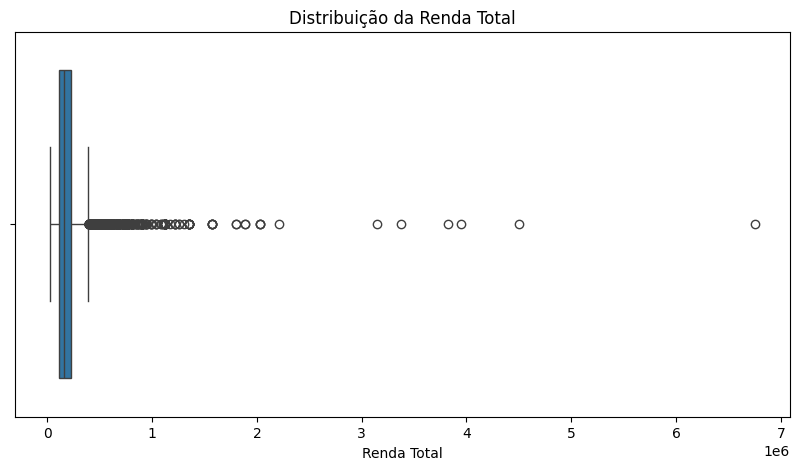

In [ ]:
#Boxplot para AMT_INCOME_TOTAL.

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_application_cleaned["AMT_INCOME_TOTAL"])
plt.title("Distribuição da Renda Total")
plt.xlabel("Renda Total")
plt.show()

A variável AMT_INCOME_TOTAL apresenta uma distribuição altamente assimétrica à direita. A média (178.700) é superior à mediana (157.500), indicando que os valores elevados de renda influenciam a distribuição. Percebe-se que a maior parte dos indivíduos possui rendas menores. A caixa em si é estreita, mas o 'bigode' superior é longo e há muitos pontos isolados acima dele. Esses pontos representam outliers com rendas significativamente mais altas, o que sugere uma grande disparidade na renda.

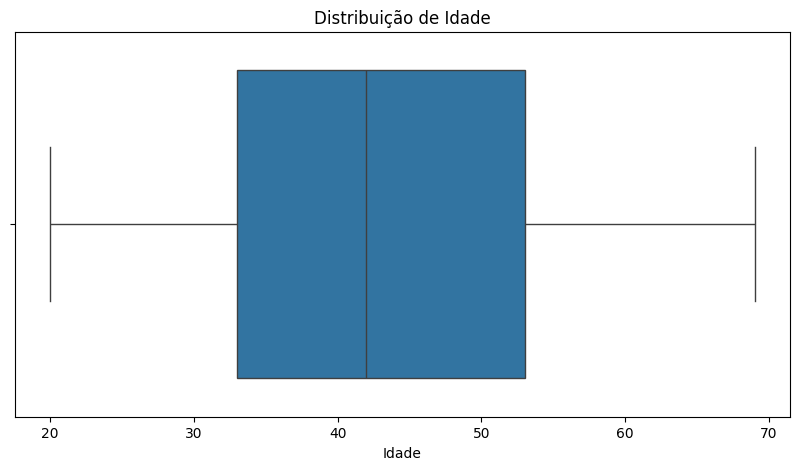

In [ ]:
#Boxplot para YEARS_BIRTH

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_application_cleaned["YEARS_BIRTH"])
plt.title("Distribuição de Idade")
plt.xlabel("Idade")
plt.show()

O boxplot para a variável YEARS_BIRTH mostra uma distribuição bastante simétrica e compacta. A caixa central, que representa a maior parte dos dados (entre o 1º e o 3º quartil), indica que a maioria dos indivíduos tem idades concentradas em uma faixa específica. A linha central da caixa (mediana) está aproximadamente no meio, confirmando a simetria. Os 'bigodes' do boxplot são de comprimentos semelhantes e não há pontos isolados visíveis, o que sugere a ausência de *outliers* extremos na distribuição de idade. Isso reforça que a população de solicitantes tem uma faixa etária bem definida e consistente.

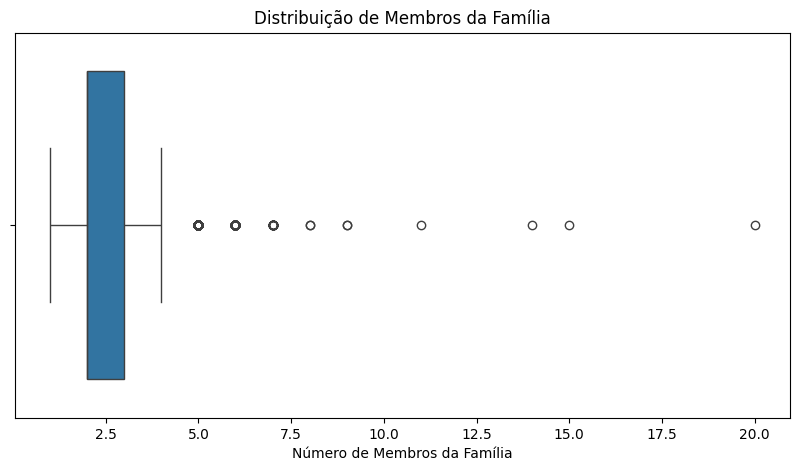

In [ ]:
#Boxplot para CNT_FAM_MEMBERS

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_application_cleaned["CNT_FAM_MEMBERS"])
plt.title("Distribuição de Membros da Família")
plt.xlabel("Número de Membros da Família")
plt.show()

A variável CNT_FAM_MEMBERS apresenta concentração de valores entre 2 e 3 membros por família. A média 2,18 e mediana 2,0 são bastante próximas, indicando distribuição relativamente equilibrada. Existem alguns pontos de dados que se estendem para um número maior de membros da família, que são considerados outliers. Isso sugere que, embora a maioria das famílias seja pequena, há uma minoria com famílias maiores, mas em menor frequência.

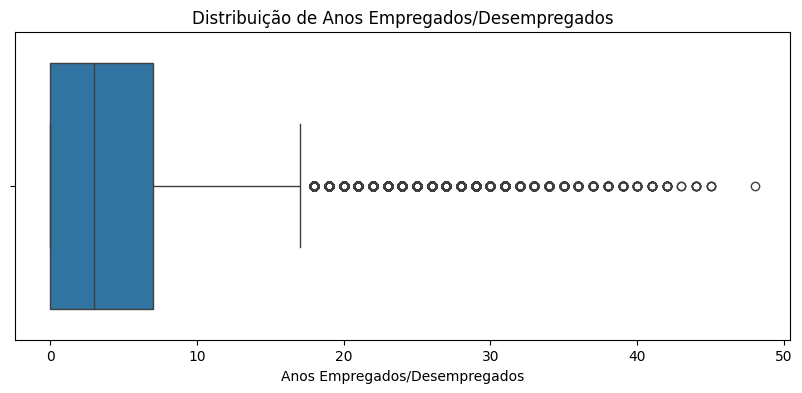

In [ ]:
#Boxplot para YEARS_EMPLOYED

plt.figure(figsize=(10,4))
sns.boxplot(x=df_application_cleaned["YEARS_EMPLOYED"])
plt.title("Distribuição de Anos Empregados/Desempregados")
plt.xlabel("Anos Empregados/Desempregados")
plt.show()

O boxplot da variável YEARS_EMPLOYED mostra uma distribuição com forte concentração no valor 0, representando os indivíduos desempregados, o que é consistente com o histograma. Para os indivíduos empregados, a caixa central é relativamente estreita e próxima do eixo Y, indicando que a maioria tem poucos anos que estão empregada. No entanto, há um 'bigode' longo à direita e a presença de muitos pontos isolados, que são *outliers* e correspondem a indivíduos com longos períodos de emprego. Isso sugere que, embora a maioria dos trabalhadores tenha menos tempo de serviço, há uma minoria significativa com muitos anos de emprego.

/tmp/ipykernel_3582/3730996598.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_application_tratado, x="CODE_GENDER", order=df_application_tratado["CODE_GENDER"].value_counts().index, palette='viridis')


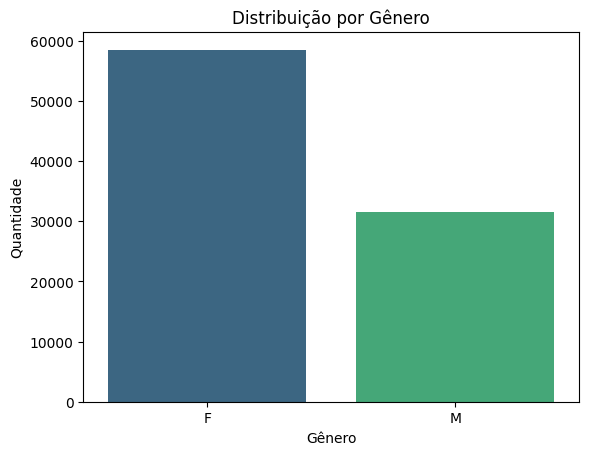

In [ ]:
#Distribuição para CODE_GENDER

sns.countplot(data=df_application_cleaned, x="CODE_GENDER", order=df_application_cleaned["CODE_GENDER"].value_counts().index, palette='viridis')
plt.title("Distribuição por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Quantidade")
plt.show()


O gráfico para CODE_GENDER mostra que a maioria dos solicitantes é do sexo feminino *(F)*, superando significativamente a quantidade de solicitantes do sexo masculino *(M)*.

/tmp/ipykernel_3582/856029801.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_application_tratado, x="OCCUPATION_TYPE", order=df_application_tratado["OCCUPATION_TYPE"].value_counts().index, palette='viridis')


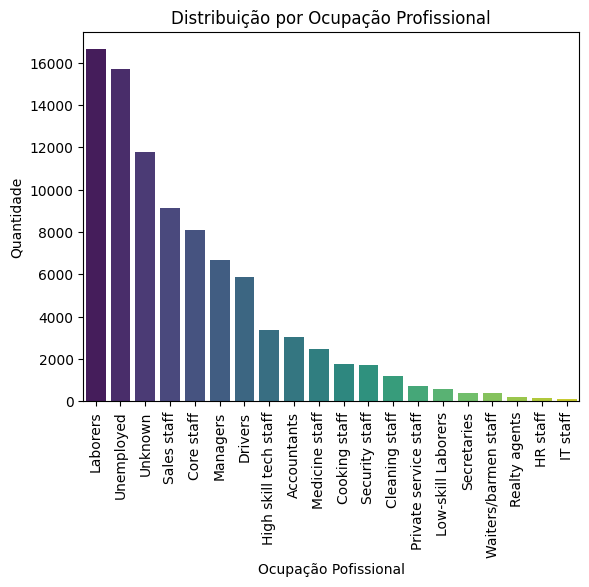

In [ ]:
#Distribuição para OCCUPATION_TYPE.

sns.countplot(data=df_application_cleaned, x="OCCUPATION_TYPE", order=df_application_cleaned["OCCUPATION_TYPE"].value_counts().index, palette='viridis')
plt.title("Distribuição por Ocupação Profissional")
plt.xlabel("Ocupação Pofissional")
plt.xticks(rotation=90)
plt.ylabel("Quantidade")
plt.show()


A distribuição de *OCCUPATION_TYPE* revela que uma grande parte dos registros tem *Unknown* como tipo de ocupação. Incluímos tal palavra para substituir os dados nulos. Entre as ocupações conhecidas, *Laborers* e *Sales staff* são as categorias mais frequentes.

/tmp/ipykernel_3582/1758848045.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_application_tratado, x="NAME_INCOME_TYPE", order=df_application_tratado["NAME_INCOME_TYPE"].value_counts().index, palette="viridis")


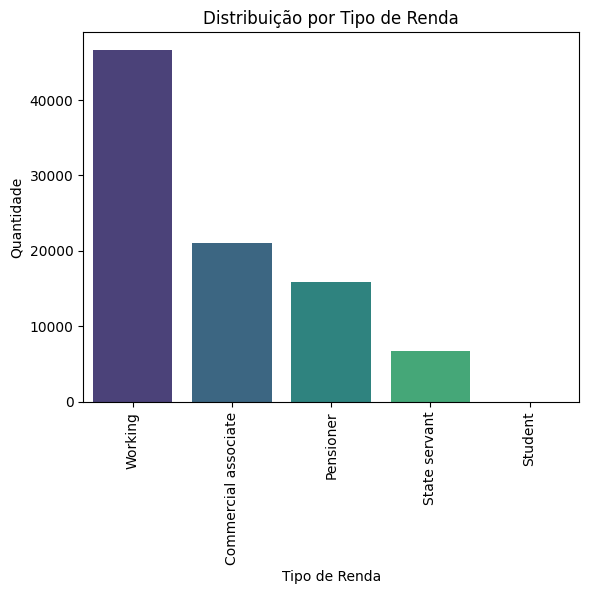

In [ ]:
#Distribuição para NAME_INCOME_TYPE.

sns.countplot(data=df_application_cleaned, x="NAME_INCOME_TYPE", order=df_application_cleaned["NAME_INCOME_TYPE"].value_counts().index, palette="viridis")
plt.title("Distribuição por Tipo de Renda")
plt.xlabel("Tipo de Renda")
plt.xticks(rotation=90)
plt.ylabel("Quantidade")
plt.show()

A variável NAME_INCOME_TYPE mostra que a maioria dos indivíduos está na categoria *Working*, seguida por *Commercial* *associate* e *Pensioner*, indicando as principais fontes de renda no dataset.

/tmp/ipykernel_3582/3900714254.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_application_tratado, x="FLAG_OWN_CAR", order=df_application_tratado["FLAG_OWN_CAR"].value_counts().index, palette="viridis")


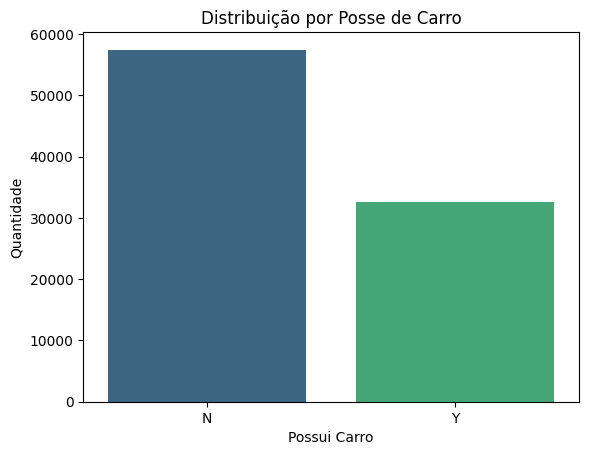

In [ ]:
#Distribuição para FLAG_OWN_CAR.

sns.countplot(data=df_application_cleaned, x="FLAG_OWN_CAR", order=df_application_cleaned["FLAG_OWN_CAR"].value_counts().index, palette="viridis")
plt.title("Distribuição por Posse de Carro")
plt.xlabel("Possui Carro")
plt.ylabel("Quantidade")
plt.show()

O gráfico para FLAG_OWN_CAR indica que a maioria *(N)* não possui carro, superando a quantidade de indivíduos que possuem *(Y)*.

/tmp/ipykernel_3582/2633810273.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_application_tratado, x="FLAG_OWN_REALTY", order=df_application_tratado["FLAG_OWN_REALTY"].value_counts().index, palette="viridis")


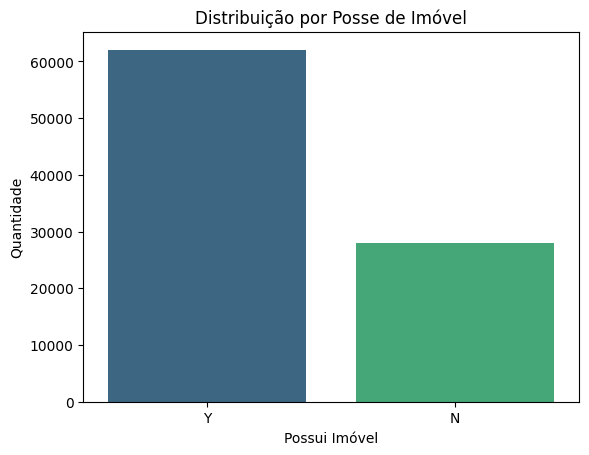

In [ ]:
#Distribuição para FLAG_OWN_REALTY.

sns.countplot(data=df_application_cleaned, x="FLAG_OWN_REALTY", order=df_application_cleaned["FLAG_OWN_REALTY"].value_counts().index, palette="viridis")
plt.title("Distribuição por Posse de Imóvel")
plt.xlabel("Possui Imóvel")
plt.ylabel("Quantidade")
plt.show()

 O countplot de FLAG_OWN_REALTY mostra que a maioria declara possuir imóveis* (Y)*, sendo a proporção significativamente maior em relação àqueles que não possuem *(N)*.

/tmp/ipykernel_3582/2527684656.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_application_tratado, x="NAME_EDUCATION_TYPE", order=df_application_tratado["NAME_EDUCATION_TYPE"].value_counts().index, palette="viridis")


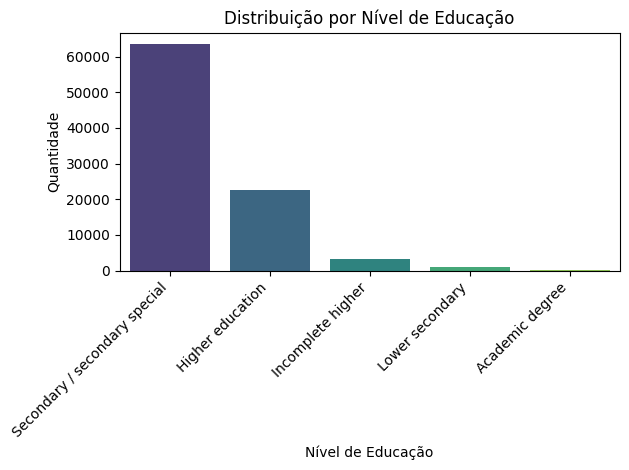

In [ ]:
#Distribuição para NAME_EDUCATION_TYPE.
sns.countplot(data=df_application_cleaned, x="NAME_EDUCATION_TYPE", order=df_application_cleaned["NAME_EDUCATION_TYPE"].value_counts().index, palette="viridis")
plt.title("Distribuição por Nível de Educação")
plt.xlabel("Nível de Educação")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

A distribuição da variável NAME_EDUCATION_TYPE revela que a maior parte dos indivíduos possui *Secondary / secondary special* seguido por *Higher education*. Outros níveis de educação são menos representados na amostra.

/tmp/ipykernel_3582/1662537450.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_application_tratado, x="NAME_HOUSING_TYPE", order=df_application_tratado["NAME_HOUSING_TYPE"].value_counts().index, palette="viridis")


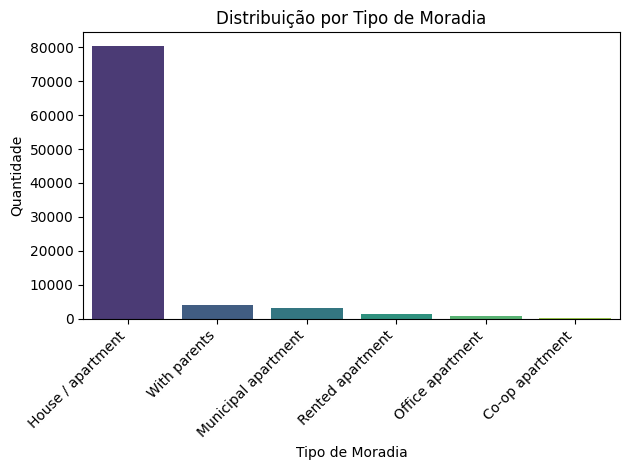

In [ ]:
#Distribuição para NAME_HOUSING_TYPE.
sns.countplot(data=df_application_cleaned, x="NAME_HOUSING_TYPE", order=df_application_cleaned["NAME_HOUSING_TYPE"].value_counts().index, palette="viridis")
plt.title("Distribuição por Tipo de Moradia")
plt.xlabel("Tipo de Moradia")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

Para NAME_HOUSING_TYPE a categoria dominante é *House / apartment* com uma parcela muito menor de solicitantes vivendo em outros tipos de moradia como *With parents* ou *Municipal apartment*.

/tmp/ipykernel_3582/4254267962.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_credit,x='STATUS',order=df_credit['STATUS'].value_counts().index, palette="viridis")


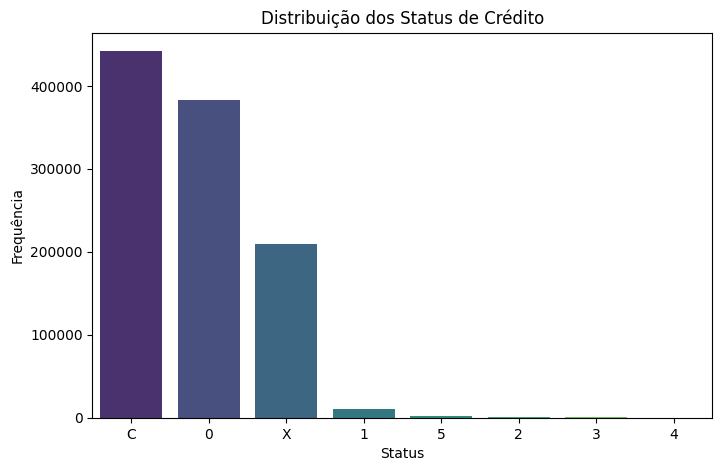

In [ ]:
#Visualizando a distribuição da variável Status.
plt.figure(figsize=(8,5))
sns.countplot(data=df_credit,x='STATUS',order=df_credit['STATUS'].value_counts().index, palette="viridis")
plt.title('Distribuição dos Status de Crédito')
plt.xlabel('Status')
plt.ylabel('Frequência')
plt.show()

O gráfico de barras mostra a frequência de cada status de crédito. As categorias 'C' (Pago) e '0' (1-29 dias de atraso) são as mais predominantes, seguidas por 'X' (Sem empréstimo no mês). As categorias de atraso mais severo (1 a 5) têm frequências muito menores, indicando que a maioria dos registros representa bom comportamento de crédito ou atrasos leves. A baixa frequência das categorias 2, 3, 4 e 5 sugere que a inadimplência grave é rara.

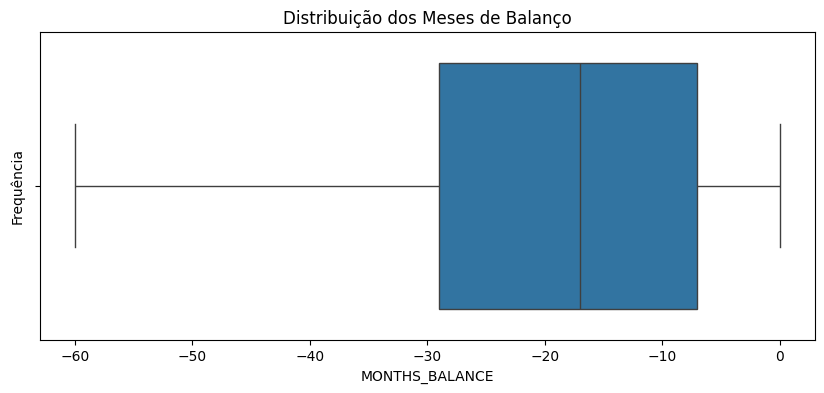

In [ ]:
#Boxplot para MONTHS_BALANCE.

plt.figure(figsize=(10,4))
sns.boxplot(x=df_credit["MONTHS_BALANCE"])
plt.title('Distribuição dos Meses de Balanço')
plt.xlabel('MONTHS_BALANCE')
plt.ylabel('Frequência')
plt.show()

O boxplot da variável MONTHS_BALANCE ilustra a distribuição dos meses de balanço dos registros de crédito. Observa-se que a maioria dos registros está concentrada em meses mais recentes (mais próximos de 0), como indicado pela caixa e pela mediana. A caixa central, que representa a maior parte dos dados, estende-se de aproximadamente -30 a -7 meses. A mediana está localizada por volta de -17 meses. Os 'bigodes' do boxplot se estendem até o valor mínimo de -60 meses e o máximo de 0 meses, mostrando todo o período de observação. Não há *outliers* visíveis neste boxplot, sugerindo que todos os registros caem dentro do intervalo esperado de tempo para o histórico de crédito.

## 3. Correlações

**Interpretação:** _comente cada correlação relevante, uma a uma._

In [ ]:
df_corr = df_application_cleaned.copy()

In [ ]:
# Mapear variáveis categóricas binárias para numéricas.
df_corr["CODE_GENDER"] = df_corr["CODE_GENDER"].map({"M": 1, "F": 0})
df_corr["FLAG_OWN_CAR"] = df_corr["FLAG_OWN_CAR"].map({"Y": 1, "N": 0})
df_corr["FLAG_OWN_REALTY"] = df_corr["FLAG_OWN_REALTY"].map({"Y": 1, "N": 0})


In [ ]:
# Selecionar as colunas numéricas para a matriz de correlação, incluindo as que foram mapeadas para numéricas.
numerical_cols = [
    "CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY", "CNT_CHILDREN",
    "AMT_INCOME_TOTAL","YEARS_BIRTH", "YEARS_EMPLOYED", "IS_UNEMPLOYED",
    "CNT_FAM_MEMBERS", "FLAG_WORK_PHONE", "FLAG_PHONE", "FLAG_EMAIL"
    ]
df_numerical_corr = df_corr[numerical_cols]

In [ ]:
# Calcular a matriz de correlação.
correlation_matrix = df_numerical_corr.corr()

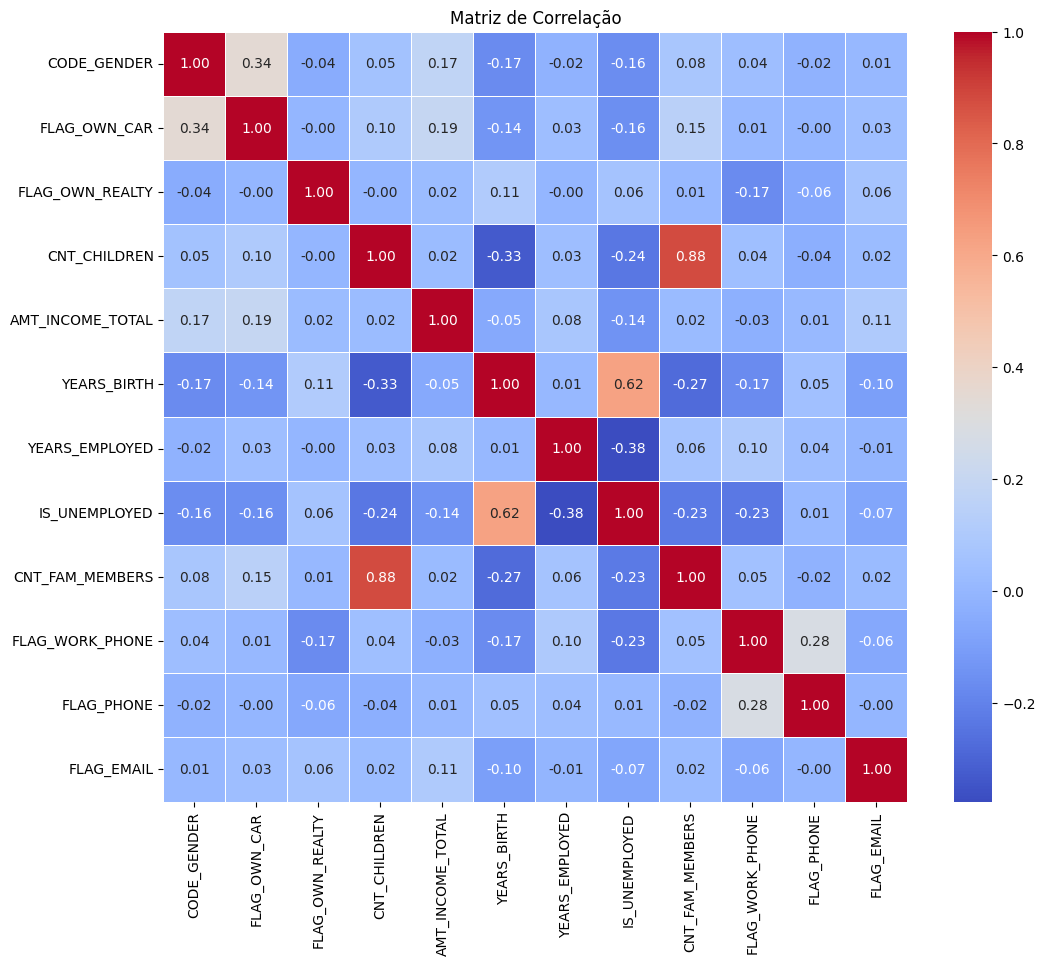

In [ ]:
# Criar o heatmap da correlação
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=.5
)
plt.title("Matriz de Correlação")
plt.show()



-Observou-se forte correlação positiva (0,88) entre o número de filhos e o número de membros da família. Esse resultado é esperado, uma vez que o aumento da quantidade de filhos contribui diretamente para o tamanho familiar.
-A correlação positiva e moderada (0,62) entre as variáveis YEARS_BIRTH (Idade) e IS_UNEMPLOYED (Status de Desemprego) indica que, nesta base de dados, quanto mais velho é o cliente, maior é a probabilidade dele estar desempregado/ inativo.
-A matriz de correlação revelou um coeficiente negativo moderado de -0,38 entre as variáveis YEARS_EMPLOYED e IS_UNEMPLOYED. Isso deve-se
à alta variabilidade no tempo de emprego dos indivíduos ativos que possuem de poucos meses a décadas de emprego formal.

### Processamento do `df_credit` para Correlação

Para unir as informações de `df_credit` com as de `df_application_tratado`, precisamos consolidar o histórico de crédito de cada cliente em uma única linha. A abordagem será:

1.  **Codificar a variável `STATUS`:** Atribuir valores numéricos que reflitam o risco de crédito.
2.  **Agregar por `ID`:** Para cada cliente, obter a pontuação de risco máximo (pior status) e o número de meses no histórico (`MONTHS_BALANCE`).

In [ ]:
# Criar uma cópia de df_credit para evitar modificar o original
df_credit_processed = df_credit.copy()

# Consolidação do histórico de crédito.
df_credit_processed["STATUS_LATED"] = df_credit_processed["STATUS"].isin(["1", "2", "3", "4", "5"]).astype(int)
df_credit_processed["STATUS_ON_TIME"] = (df_credit_processed["STATUS"] =="0").astype(int)
df_credit_processed["STATUS_CLOSED"] = (df_credit_processed["STATUS"] =="C").astype(int)
df_credit_processed["STATUS_NO_CREDIT"] = (df_credit_processed["STATUS"] =="X").astype(int)

## 4. Outliers

**Interpretação:** _remover, winsorizar ou manter? Justifique._

### Detecção e Tratamento de Outliers para `AMT_INCOME_TOTAL`

Vamos usar o método do Intervalo Interquartil (IQR) para identificar os *outliers* na variável `AMT_INCOME_TOTAL`. O IQR é a diferença entre o terceiro quartil (Q3) e o primeiro quartil (Q1). Valores abaixo de `Q1 - 1.5 * IQR` ou acima de `Q3 + 1.5 * IQR` serão considerados *outliers*.

Para tratar esses *outliers*, aplicaremos o *capping*, ou seja, substituiremos os valores que ultrapassam o limite superior pelo próprio limite superior, e os valores abaixo do limite inferior pelo próprio limite inferior. Isso ajuda a reduzir o impacto de valores extremos sem remover os dados.

In [ ]:
# detecção de outliers

## 5. Balanceamento de classes

**Interpretação:** _qual a proporção entre as classes e o que isso implica na escolha das métricas?_

## 6. Síntese da EDA

_Amarre os achados em uma narrativa única — é ela que vira o storytelling da apresentação._